# Drive Shaping Methods

A quantum program in the Rydberg analog model is defined as a time-dependent drive Hamiltonian that is imposed on the qubits (in addition to the interaction Hamiltonian). The drive shaping configuration part (the `drive_shaping` field of `SolverConfig`) defines how the drive parameters are constructed.

In this notebook, we show how to use different drive shaping methods:

- `PROPORTIONAL_DIAGONAL` *(Has no parameters to be customized).*
- `BAYESIAN_SEARCH` *(Has seven parameters that can be customized).*

We choose the method when defining the `SolverConfig` configuration, with `drive_shaping_method = DriveType.(method)`

**Default SolverConfig parameters to run a quantum approach:**
- use_quantum: bool = False (*for using the drive shaping methods, we have to set it to `True`.*)
- backend: LocalEmulator | RemoteEmulator | QPU (by default, use a LocalEmulator based on qutip)
- device: Device = AnalogDeviceWithDMM() (also available: `AnalogDevice()`)
- embedding_method: str | EmbedderType | None = EmbedderType.GREEDY (also available: `BLADE`)
- drive_shaping_method: str | DriveType | None = DriveType.PROPORTIONAL_DIAGONAL (also available: `BAYESIAN_SEARCH`)


In [ ]:
from qubosolver import Instance, SolverConfig, DriveShapingConfig, DriveType, Solver, matrix, Matrix, Solution

import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"

%matplotlib inline

** Create the <code>Instance</code> **

Here, we have a 3x3 QUBO matrix with negative diagonal and positive off-diagonal terms.

In [ ]:
coefficients = matrix.tensor([[-1.0, 0.5, 0.2], [0.5, -2.0, 0.3], [0.2, 0.3, -3.0]])
instance = Instance(coefficients)

## Proportional-Diagonal Drive Shaper

Default method


[PROPORTIONAL_DIAGONAL] num_shots=500
Solution object:
Solution(bitstrings=tensor([[0, 1, 1, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 1],
        [1, 1, 0, 1]], dtype=torch.int8), costs=tensor([-11.0000, -10.5000, -10.0000,  -8.5000]), counts=tensor([  5, 470,  23,   2]), probabilities=tensor([0.0100, 0.9400, 0.0460, 0.0040]))
Best sampled cost: -11.0
Best sampled bitstring: [0, 1, 1, 0]

[PROPORTIONAL_DIAGONAL] num_shots=500
Solution object:
Solution(bitstrings=tensor([[0, 1, 1, 0],
        [0, 1, 0, 1],
        [0, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 1, 0, 1]], dtype=torch.int8), costs=tensor([-11.0000, -10.5000, -10.5000, -10.0000,  -9.5000,  -8.5000]), counts=tensor([  2, 471,   2,  11,   1,  13]), probabilities=tensor([0.0040, 0.9420, 0.0040, 0.0220, 0.0020, 0.0260]))
Best sampled cost: -11.0
Best sampled bitstring: [0, 1, 1, 0]

################################################################################
COMPARISON (best sampled cost):
PROPOR

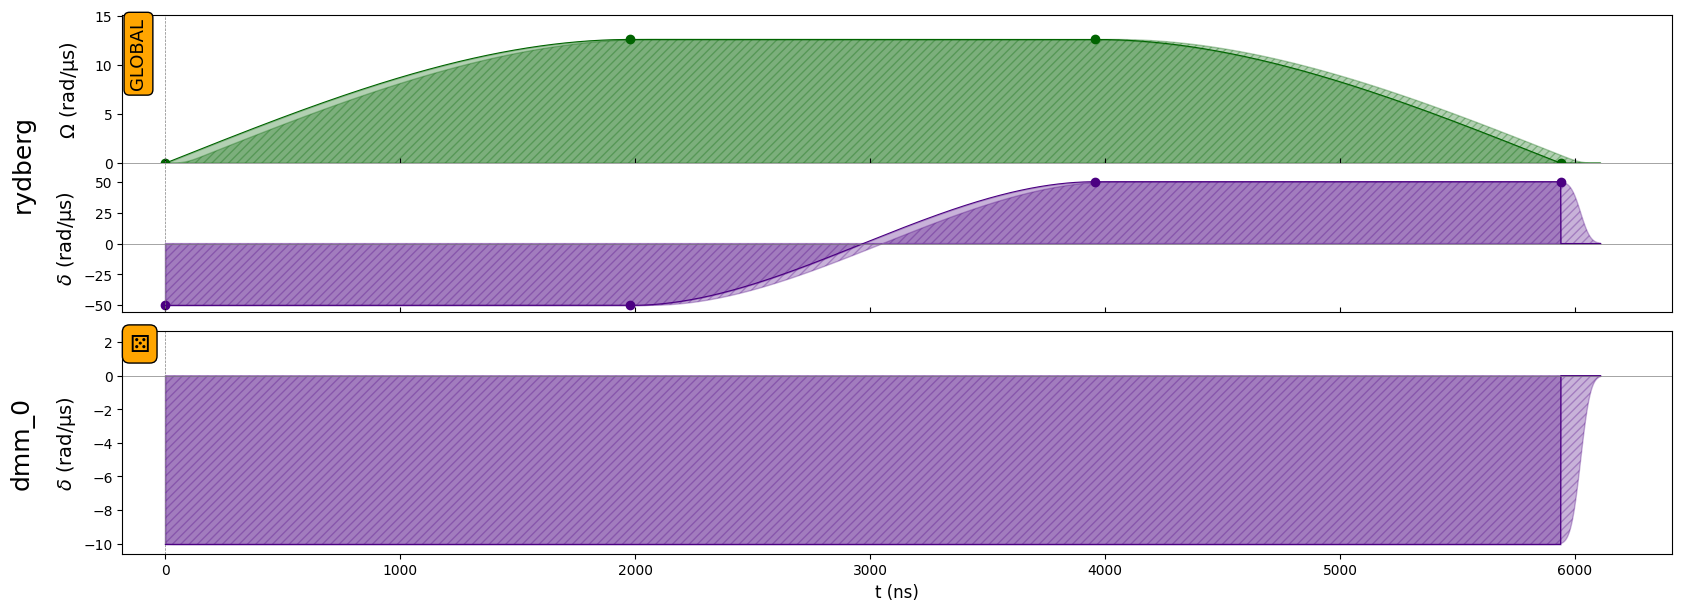

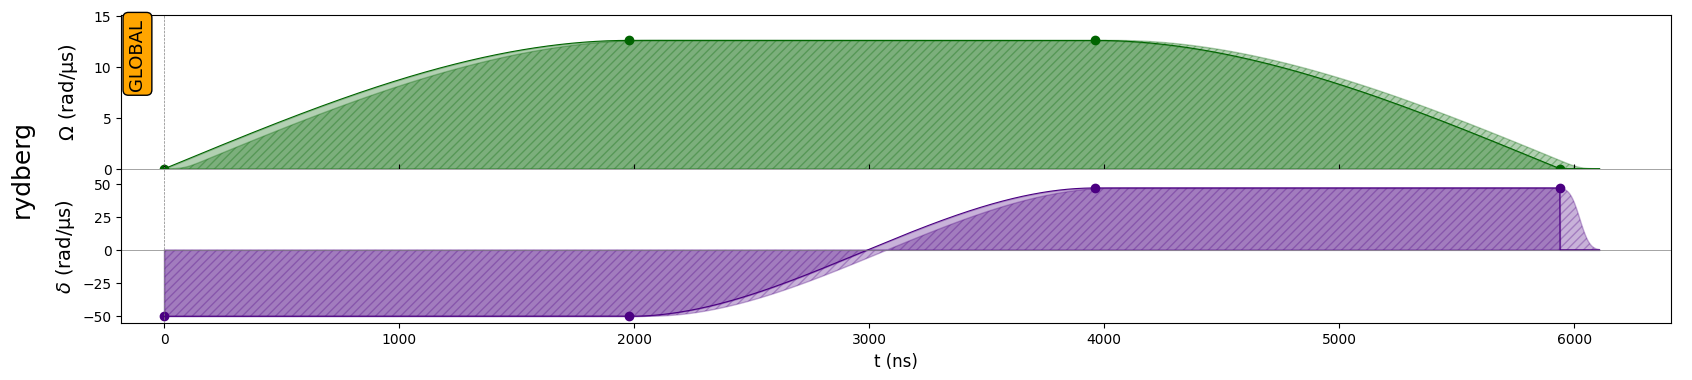

In [ ]:
import torch

from qubosolver import Instance, EmbeddingConfig, LocalEmulator

from pulser_simulation import QutipBackendV2


def run_one(method: DriveType, q: Matrix, num_shots: int = 500, dmm: bool = True):
    instance = Instance(matrix=q)

    embed_cfg = EmbeddingConfig(
        embedding_method="greedy",
        greedy_traps=6,
        # pas de greedy_spacing => default
    )

    drive_cfg = DriveShapingConfig(
        drive_shaping_method=method,
        dmm=dmm,
    )

    backend = LocalEmulator(backend_type=QutipBackendV2, num_shots=num_shots)

    config = SolverConfig(
        use_quantum=True,
        embedding=embed_cfg,
        drive_shaping=drive_cfg,
        backend=backend,
    )

    solver = Solver(instance, config)

    # solve (inclut exécution + mesure)
    sol = solver.solve()

    # afficher la séquence
    embedding = solver.embedding()
    drive = solver.drive(embedding)[0]
    solver.draw_sequence(drive, embedding)

    tag = "PROPORTIONAL_DIAGONAL"
    print("\n" + "=" * 80)
    print(f"[{tag}] num_shots={num_shots}")
    print("Solution object:")
    print(sol)
    print(f"Best sampled cost: {sol[0].cost}")
    print(f"Best sampled bitstring: {sol[0].string}")

    return sol, sol[0].cost, sol[0].string


if __name__ == "__main__":
    Q1 = matrix.tensor([
        [-6.0,  2.0,  2.0,  2.0],
        [ 2.0, -7.5,  2.0,  2.0],
        [ 2.0,  2.0, -7.5,  2.0],
        [ 2.0,  2.0,  2.0, -7.0],
    ])

    sol_h_dmm, best_h_dmm, bs_h_dmm = run_one(DriveType.PROPORTIONAL_DIAGONAL, Q1, num_shots=500, dmm=True)
    sol_h_nodmm, best_h_nodmm, bs_h_nodmm = run_one(DriveType.PROPORTIONAL_DIAGONAL, Q1, num_shots=500, dmm=False)

    print("\n" + "#" * 80)
    print("COMPARISON (best sampled cost):")
    print(f"PROPORTIONAL_DIAGONAL (dmm=True) : {best_h_dmm}  bitstring={bs_h_dmm}")
    print(f"PROPORTIONAL_DIAGONAL (dmm=False): {best_h_nodmm}  bitstring={bs_h_nodmm}")

# Local-Energy-Scale Drive Heuristic

This notebook demonstrates how to solve a QUBO using the
**local-energy-scale drive heuristic**, with and without a Detuning Map
Modulator (DMM).

For each qubit \(i\), the heuristic defines the local physical energy scale

$$
E_i =
\left|\delta_i(T)\right|
+
\sum_{j \neq i} \left|V_{ij}\right|.
$$

The peak Rabi frequency is then defined as

$$
\Omega_{\max}
=
\kappa
\frac{1}{N}
\sum_{i=1}^{N} E_i.
$$

The notebook runs the same QUBO with `dmm=True` and `dmm=False`, displays
the generated drive sequences, and compares the best sampled solutions.


[LOCAL_ENERGY_SCALE] dmm=True, kappa=0.25, num_shots=500
Solution object:
Solution(bitstrings=tensor([[0, 1, 0, 1],
        [0, 1, 1, 1],
        [1, 1, 0, 1]], dtype=torch.int8), costs=tensor([-10.5000, -10.0000,  -8.5000]), counts=tensor([354, 136,  10]), probabilities=tensor([0.7080, 0.2720, 0.0200]))
Best sampled cost: -10.5
Best sampled bitstring: [0, 1, 0, 1]

[LOCAL_ENERGY_SCALE] dmm=False, kappa=0.25, num_shots=500
Solution object:
Solution(bitstrings=tensor([[0, 1, 1, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 1],
        [1, 0, 1, 0],
        [1, 0, 0, 1],
        [1, 1, 0, 1]], dtype=torch.int8), costs=tensor([-11.0000, -10.5000, -10.0000,  -9.5000,  -9.0000,  -8.5000]), counts=tensor([  1, 391,  55,   1,   1,  51]), probabilities=tensor([0.0020, 0.7820, 0.1100, 0.0020, 0.0020, 0.1020]))
Best sampled cost: -11.0
Best sampled bitstring: [0, 1, 1, 0]

################################################################################
COMPARISON (best sampled cost):
LOCAL_ENERGY

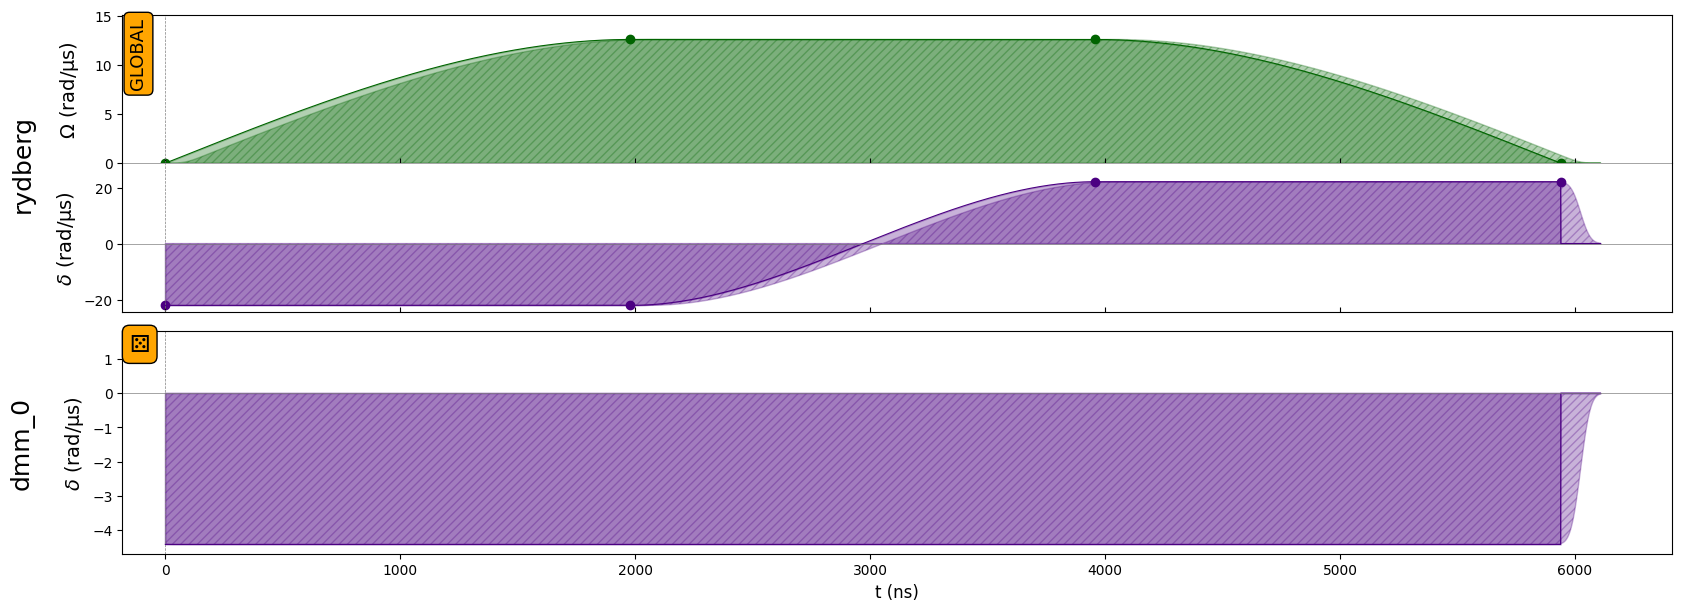

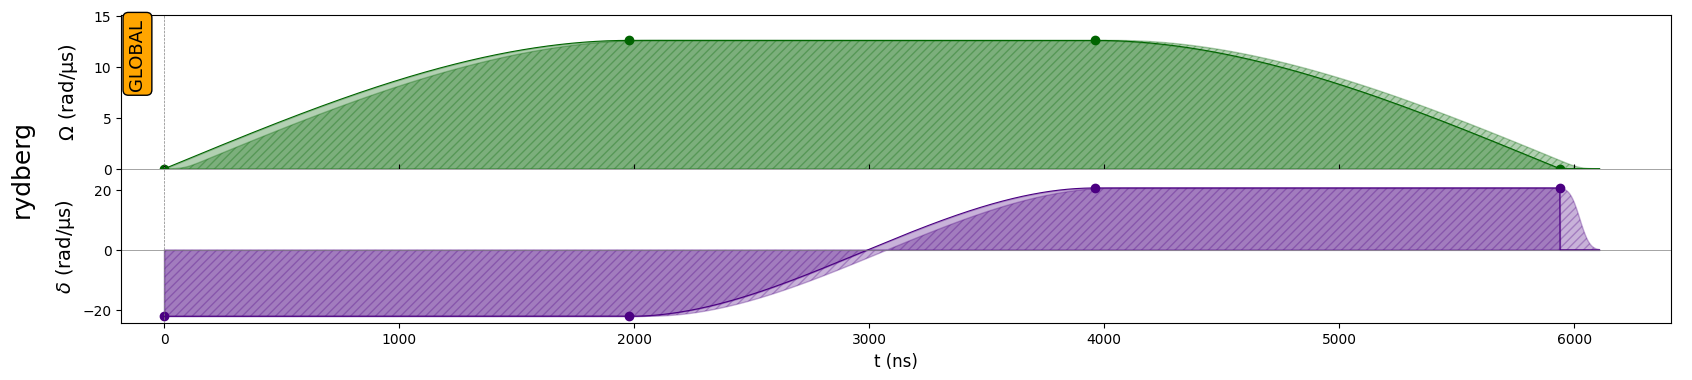

In [ ]:


from qubosolver import (
    DriveType,
    Instance,
    matrix,
)

def run_one(
    q,
    num_shots=500,
    dmm=True,
    kappa=0.25,
):
    instance = Instance(q)

    embed_cfg = EmbeddingConfig(
        embedding_method="greedy",
        greedy_traps=6,
    )

    drive_cfg = DriveShapingConfig(
        drive_shaping_method= DriveType.LOCAL_ENERGY_SCALE,
        dmm=dmm,
        local_energy_scale_kappa=kappa,
    )

    backend = LocalEmulator(
        backend_type=QutipBackendV2,
        num_shots=num_shots,
    )

    config = SolverConfig(
        use_quantum=True,
        embedding=embed_cfg,
        drive_shaping=drive_cfg,
        backend=backend,
    )

    solver = Solver(instance, config)

    # Solve the QUBO, including execution and sampling.
    sol = solver.solve()

    # Display the generated sequence.
    embedding = solver.embedding()
    drive, _ = solver.drive(embedding)

    solver.draw_sequence(drive, embedding)

    tag = "LOCAL_ENERGY_SCALE"

    print("\n" + "=" * 80)
    print(f"[{tag}] dmm={dmm}, kappa={kappa}, num_shots={num_shots}")
    print("Solution object:")
    print(sol)
    print(f"Best sampled cost: {sol[0].cost}")
    print(f"Best sampled bitstring: {sol[0].string}"
    )

    return sol, sol[0].cost, sol[0].string


Q1 = matrix.tensor(
    [
        [-6.0, 2.0, 2.0, 2.0],
        [2.0, -7.5, 2.0, 2.0],
        [2.0, 2.0, -7.5, 2.0],
        [2.0, 2.0, 2.0, -7.0],
    ]
)


sol_les_dmm, best_les_dmm, bs_les_dmm = (
    run_one(
        Q1,
        num_shots=500,
        dmm=True,
        kappa=0.25,
    )
)

sol_les_nodmm, best_les_nodmm, bs_les_nodmm = (
    run_one(
        Q1,
        num_shots=500,
        dmm=False,
        kappa=0.25,
    )
)

print("\n" + "#" * 80)
print("COMPARISON (best sampled cost):")
print(f"LOCAL_ENERGY_SCALE (dmm=True): {best_les_dmm} bitstring={bs_les_dmm}")
print(f"LOCAL_ENERGY_SCALE (dmm=False): {best_les_nodmm}  bitstring={bs_les_nodmm}")

## Bayesian Search Drive shaping 

#### Parameters to customize:

For the BAYESIAN_SEARCH drive shaping, we have the following parameters:
- bayesian_search_n_calls: Number of calls for the optimization process.
- bayesian_search_re_execute_opt_drive: Whether to re-run the optimal drive sequence after optimization.
- bayesian_search_initial_omega_parameters: Default initial omega parameters for the drive. Defaults to (1, 2, 1).
- bayesian_search_initial_detuning_parameters: Default initial detuning parameters for the drive. Defaults to (-2, 0, 2).

#### Default configuration

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.BAYESIAN_SEARCH),
)
solver = Solver(instance, default_config)

solution = solver.solve()
print(solution)

Solution(bitstrings=tensor([[0, 1, 1],
        [1, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int8), costs=tensor([-4.4000, -4.0000, -3.6000, -3.0000, -2.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([281,  44,  55, 314, 129,  27,  22, 128]), probabilities=tensor([0.2810, 0.0440, 0.0550, 0.3140, 0.1290, 0.0270, 0.0220, 0.1280]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing <code>bayesian_search_n_calls</code>

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.BAYESIAN_SEARCH, bayesian_search_n_calls=13),
)
solver = Solver(instance, default_config)

solution = solver.solve()
print(solution)

Solution(bitstrings=tensor([[0, 1, 1],
        [1, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int8), costs=tensor([-4.4000, -4.0000, -3.6000, -3.0000, -2.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([303,  51,  51, 301, 125,  15,  21, 133]), probabilities=tensor([0.3030, 0.0510, 0.0510, 0.3010, 0.1250, 0.0150, 0.0210, 0.1330]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing the initial parameters

Initial parameters of the optimization procedure can be changed as `bayesian_search_initial_omega_parameters` and `bayesian_search_initial_detuning_parameters`

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.BAYESIAN_SEARCH, bayesian_search_initial_omega_parameters=[0.5, 0.9, 0.5,], bayesian_search_initial_detuning_parameters=[-0.9, 0.0, 0.5]),
)
solver = Solver(instance, default_config)

solution = solver.solve()
print(solution)

Solution(bitstrings=tensor([[0, 1, 1],
        [1, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
        [1, 1, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int8), costs=tensor([-4.4000, -4.0000, -3.6000, -3.0000, -2.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([367, 123,  65, 208,  56,  95,  24,  62]), probabilities=tensor([0.3670, 0.1230, 0.0650, 0.2080, 0.0560, 0.0950, 0.0240, 0.0620]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing <code>bayesian_search_re_execute_opt_drive</code>

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.BAYESIAN_SEARCH, bayesian_search_re_execute_opt_drive=True),
)
solver = Solver(instance, default_config)

solution = solver.solve()
print(solution)

Solution(bitstrings=tensor([[0, 1, 1],
        [1, 1, 1],
        [1, 0, 1],
        [0, 0, 1],
        [1, 1, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0]], dtype=torch.int8), costs=tensor([-4.4000, -4.0000, -3.6000, -3.0000, -2.0000, -2.0000, -1.0000,  0.0000]), counts=tensor([270,  43,  59, 329,  14, 114,  22, 149]), probabilities=tensor([0.2700, 0.0430, 0.0590, 0.3290, 0.0140, 0.1140, 0.0220, 0.1490]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Adding custom functions

One can change the drive shaping method by incorporating custom functions for:
- Evaluating a candidate bitstring and QUBO via `bayesian_search_custom_qubo_cost`
- Performing optimization with a different objective than the best cost via `bayesian_search_custom_objective`
- Adding callback functions via `bayesian_search_callback_objective`.

In [ ]:
from qubosolver.utils._costs import quadratic_cost

# example of penalization
def penalized_qubo(bitstring: torch.Tensor, QUBO: torch.Tensor) -> float:
    return quadratic_cost(bitstring, QUBO) + 2.0 * (bitstring == 0).sum().item()

# example of saving intermediate results
opt_results = list()
def callback(d: dict) -> None:
    opt_results.append(d)

# example of using an average cost
def average_ojective(
    solution: Solution,
) -> float:
    return sum([p.item() * c.item() for p, c in zip(solution.probabilities, solution.costs)])

drive_shaping=DriveShapingConfig(drive_shaping_method=DriveType.BAYESIAN_SEARCH, 
    bayesian_search_re_execute_opt_drive=True,
    bayesian_search_custom_qubo_cost=penalized_qubo, 
    bayesian_search_callback_objective=callback,
    bayesian_search_custom_objective=average_ojective,
)

config = SolverConfig(
    use_quantum=True, 
    drive_shaping=drive_shaping,
)

In [ ]:
solver = Solver(instance, config)
solution = solver.solve()
len(opt_results), opt_results[-1]

(20,
 {'x': [0.9999,
   0.8762939460837834,
   0.69906528971653,
   -0.6910607103462159,
   0.18689943543596232,
   0.4031925944615426],
  'cost_eval': -2.881000099280849})

In [ ]:
solution

Solution(bitstrings=tensor([[0, 0, 1]], dtype=torch.int32), costs=tensor([-3.]), counts=tensor([1000]), probabilities=tensor([1.]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)